# Pretraining Analysis — SIC Curves

Fig 2 (Gaussian noise robustness) and Fig 3 (extended feature sets) for each pretraining strategy:
ref-vs-ref, supervised, autoencoder, MFP, SCARF SSL.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import matplotlib.cm as col
from matplotlib.lines import Line2D
import warnings, os
warnings.filterwarnings("ignore")

In [2]:
RES     = "/pscratch/sd/z/zgillis/results/"
NN_runs = "50"          # ensemble file tag for plain NN baselines

FIGSIZE   = (7, 5)
YLIM_FIG2 = 17          # Gaussian noise plots
YLIM_FIG3 = 40.15       # extended feature set plots

max_err = 0.2
S = 20000
B = 312858

plt.rcParams.update({
    "pgf.rcfonts":              False,
    "font.serif":               [],
    "axes.formatter.useoffset": False,
    "lines.linewidth":          2,
    "errorbar.capsize":         2,
    "grid.linewidth":           0.5,
    "axes.labelsize":           14,
    "axes.titlesize":           16,
    "xtick.labelsize":          12,
    "ytick.labelsize":          12,
    "legend.title_fontsize":    12,
    "legend.fontsize":          12,
    "legend.frameon":           False,
})

In [3]:
colormap_gaussian = col.get_cmap("viridis")
_N = 6
col_1G  = colormap_gaussian(1/_N)
col_2G  = colormap_gaussian(2/_N)
col_5G  = colormap_gaussian(3/_N)
col_10G = colormap_gaussian(4/_N)
col_30G = colormap_gaussian(5/_N)
col_50G = colormap_gaussian(6/_N)

col_bas = "black"
col_ex1 = "r"
col_ex2 = "orange"
col_ex3 = "dodgerblue"

In [4]:
def mean_and_percentiles(x_arrays, y_arrays, number=1000):
    x_values = np.linspace(0.01, 1, number)
    y_values = np.zeros((len(y_arrays), len(x_values)))
    for j in range(len(y_arrays)):
        y_values[j] = interp1d(x_arrays[j], y_arrays[j])(x_values)
    py = 1 / y_values
    y_mean = np.median(py, axis=0)
    inds = np.argwhere(y_mean < B * max_err**2)[:, 0]
    y_max = np.percentile(py, 84, axis=0)
    y_min = np.percentile(py, 16, axis=0)
    return x_values[inds], y_mean[inds], y_min[inds], y_max[inds]


def plot_fn(tpr, fpr, color, label, linestyle, alpha=0.2):
    tpr_m, fpr_m, fpr_lo, fpr_hi = mean_and_percentiles(tpr, fpr)
    plt.plot(tpr_m, tpr_m * np.sqrt(fpr_m), color=color, label=label, linestyle=linestyle)
    plt.fill_between(tpr_m, tpr_m * np.sqrt(fpr_lo), tpr_m * np.sqrt(fpr_hi),
                     alpha=alpha, facecolor=color)


def import_and_plot(path, label=None, color="grey", folder="rocs/",
                    N_runs=10, start_runs=0, alpha=0.2, linestyle="solid"):
    fpr = np.load(folder + "fpr_" + path + ".npy")[start_runs:start_runs + N_runs]
    tpr = np.load(folder + "tpr_" + path + ".npy")[start_runs:start_runs + N_runs]
    plot_fn(tpr, fpr, color, label, linestyle, alpha=alpha)


def plot_end(name, ylim=None):
    plt.ylabel(r"$\epsilon_S/\sqrt{\epsilon_B}$")
    plt.xlabel(r"$\epsilon_S$")
    plt.xlim(0, 1)
    if ylim is not None:
        plt.ylim(0, ylim)
    plt.legend(loc="upper right")
    os.makedirs("plots", exist_ok=True)
    plt.savefig("plots/sic_" + name + ".pdf", bbox_inches="tight", dpi=300)
    plt.show()


def plot_comparison(fig_name, rows, method_label, ylim):
    """
    rows: list of (label, color, nn_dir, bdt_dir, method_dir, ens_file, n_ens)
      bdt_dir=None    → skip BDT solid line for that row
      method_dir=None → skip method dotted line for that row (data not available)
    """
    plt.figure(figsize=FIGSIZE)
    for label, color, nn_dir, bdt_dir, method_dir, ens_file, n_ens in rows:
        if bdt_dir is not None:
            import_and_plot("roc_classifier_averaging",
                            label=label, color=color, linestyle="solid", folder=RES + bdt_dir)
        import_and_plot(NN_runs + "_temp",
                        label=None if bdt_dir else label,
                        color=color, linestyle="dashed", folder=RES + nn_dir, N_runs=1)
        if method_dir is not None:
            import_and_plot(ens_file,
                            label=None, color=color, linestyle="dotted",
                            folder=RES + method_dir, N_runs=n_ens)
    # Second legend: linestyle guide
    style_handles = [
        Line2D([0], [0], color="grey", linestyle="solid",  label="BDT"),
        Line2D([0], [0], color="grey", linestyle="dashed", label="NN (no pretraining)"),
        Line2D([0], [0], color="grey", linestyle="dotted", label=method_label),
    ]
    plt.gca().add_artist(plt.legend(handles=style_handles, loc="center right"))
    plot_end(fig_name, ylim=ylim)

---
# 1. Ref-vs-ref (pretrained on SR ref vs SR ref)

> No baseline condition — ref-vs-ref pretraining requires noise features to have an effect.

## Fig 2 — Gaussian noise

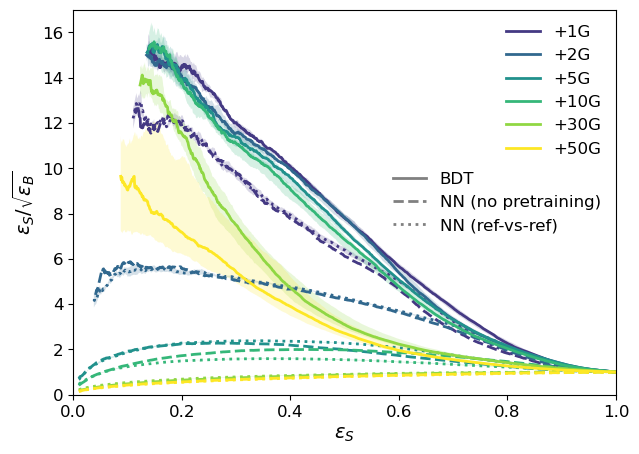

In [5]:
rows = [
    # (label,  color,  nn_dir,         bdt_dir,        method_dir,                 ens_file,   n_ens)
    ("+1G",  col_1G,  "IAD_NN_1G/",  "IAD_BDT_1G/",  "IAD_NN_pretrained_1G/",   "50_temp",  2),
    ("+2G",  col_2G,  "IAD_NN_2G/",  "IAD_BDT_2G/",  "IAD_NN_pretrained_2G/",   "50_temp",  2),
    ("+5G",  col_5G,  "IAD_NN_5G/",  "IAD_BDT_5G/",  "IAD_NN_pretrained_5G/",   "50_temp",  2),
    ("+10G", col_10G, "IAD_NN_10G/", "IAD_BDT_10G/", "IAD_NN_pretrained_10G/",  "50_temp",  2),
    ("+30G", col_30G, "IAD_NN_30G/", "IAD_BDT_30G/", "IAD_NN_pretrained_30G/",  "50_temp",  2),
    ("+50G", col_50G, "IAD_NN_50G/", "IAD_BDT_50G/", "IAD_NN_pretrained_50G/",  "50_temp",  2),
]
plot_comparison("fig2_refvsref", rows, "NN (ref-vs-ref)", ylim=YLIM_FIG2)

## Fig 3 — Extended feature sets

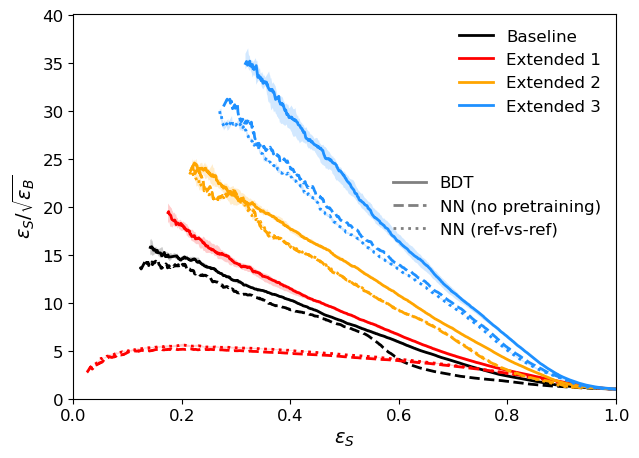

In [6]:
rows = [
    ("Baseline",    col_bas, "IAD_baseline_NN/",  "IAD_baseline_BDT/",  None,                            None,      0),
    ("Extended 1",  col_ex1, "IAD_NN_extended1/", "IAD_BDT_extended1/", "IAD_NN_pretrained_extended1/",  "50_temp", 2),
    ("Extended 2",  col_ex2, "IAD_NN_extended2/", "IAD_BDT_extended2/", "IAD_NN_pretrained_extended2/",  "50_temp", 2),
    ("Extended 3",  col_ex3, "IAD_NN_extended3/", "IAD_BDT_extended3/", "IAD_NN_pretrained_extended3/",  "50_temp", 2),
]
plot_comparison("fig3_refvsref", rows, "NN (ref-vs-ref)", ylim=YLIM_FIG3)

---
# 2. Supervised pretraining (oracle upper bound)

## Fig 2 — Gaussian noise

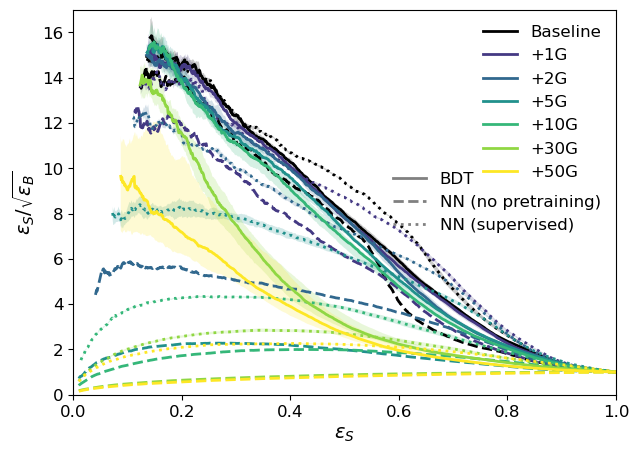

In [7]:
rows = [
    ("Baseline", col_bas, "IAD_baseline_NN/", "IAD_baseline_BDT/", "IAD_NN_supervised_baseline/", "50_temp", 2),
    ("+1G",  col_1G,  "IAD_NN_1G/",  "IAD_BDT_1G/",  "IAD_NN_supervised_1G/",  "50_temp", 2),
    ("+2G",  col_2G,  "IAD_NN_2G/",  "IAD_BDT_2G/",  "IAD_NN_supervised_2G/",  "50_temp", 2),
    ("+5G",  col_5G,  "IAD_NN_5G/",  "IAD_BDT_5G/",  "IAD_NN_supervised_5G/",  "50_temp", 2),
    ("+10G", col_10G, "IAD_NN_10G/", "IAD_BDT_10G/", "IAD_NN_supervised_10G/", "50_temp", 2),
    ("+30G", col_30G, "IAD_NN_30G/", "IAD_BDT_30G/", "IAD_NN_supervised_30G/", "50_temp", 2),
    ("+50G", col_50G, "IAD_NN_50G/", "IAD_BDT_50G/", "IAD_NN_supervised_50G/", "50_temp", 2),
]
plot_comparison("fig2_supervised", rows, "NN (supervised)", ylim=YLIM_FIG2)

## Fig 3 — Extended feature sets

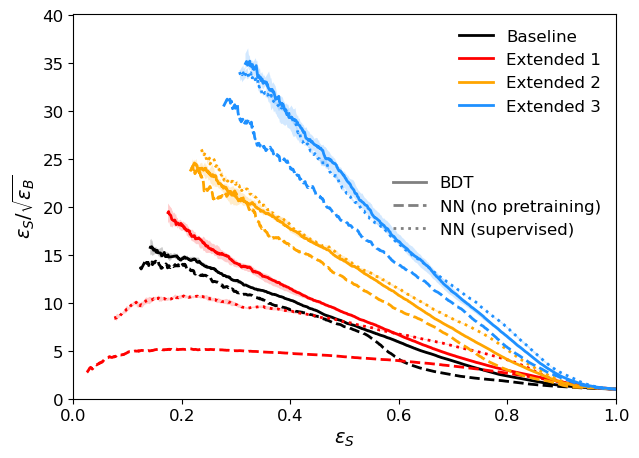

In [8]:
rows = [
    ("Baseline",   col_bas, "IAD_baseline_NN/",  "IAD_baseline_BDT/",  None,                              None,      0),
    ("Extended 1", col_ex1, "IAD_NN_extended1/", "IAD_BDT_extended1/", "IAD_NN_supervised_extended1/",   "50_temp", 2),
    ("Extended 2", col_ex2, "IAD_NN_extended2/", "IAD_BDT_extended2/", "IAD_NN_supervised_extended2/",   "50_temp", 2),
    ("Extended 3", col_ex3, "IAD_NN_extended3/", "IAD_BDT_extended3/", "IAD_NN_supervised_extended3/",   "50_temp", 2),
]
plot_comparison("fig3_supervised", rows, "NN (supervised)", ylim=YLIM_FIG3)

---
# 3. Autoencoder pretraining

## Fig 2 — Gaussian noise

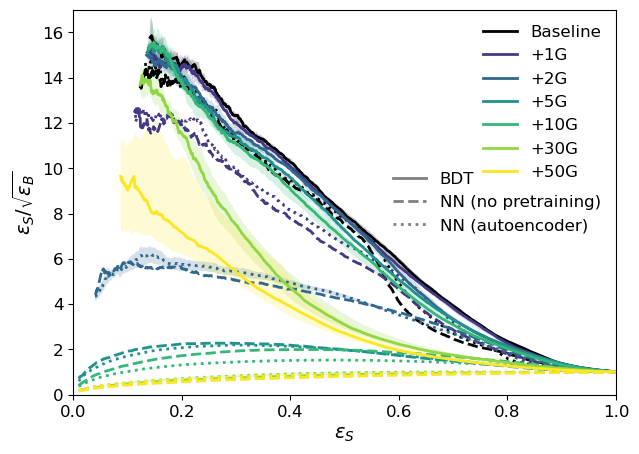

In [9]:
rows = [
    ("Baseline", col_bas, "IAD_baseline_NN/", "IAD_baseline_BDT/", "IAD_NN_autoencoder_baseline/", "50_temp", 1),
    ("+1G",  col_1G,  "IAD_NN_1G/",  "IAD_BDT_1G/",  "IAD_NN_autoencoder_1G/",  "50_temp", 1),
    ("+2G",  col_2G,  "IAD_NN_2G/",  "IAD_BDT_2G/",  "IAD_NN_autoencoder_2G/",  "50_temp", 2),
    ("+5G",  col_5G,  "IAD_NN_5G/",  "IAD_BDT_5G/",  "IAD_NN_autoencoder_5G/",  "50_temp", 2),
    ("+10G", col_10G, "IAD_NN_10G/", "IAD_BDT_10G/", "IAD_NN_autoencoder_10G/", "50_temp", 2),
    ("+30G", col_30G, "IAD_NN_30G/", "IAD_BDT_30G/", "IAD_NN_autoencoder_30G/", "50_temp", 2),
    ("+50G", col_50G, "IAD_NN_50G/", "IAD_BDT_50G/", "IAD_NN_autoencoder_50G/", "50_temp", 2),
]
plot_comparison("fig2_autoencoder", rows, "NN (autoencoder)", ylim=YLIM_FIG2)

## Fig 3 — Extended feature sets

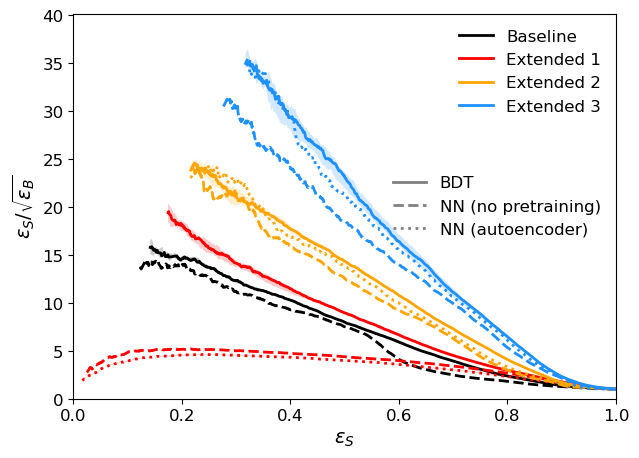

In [10]:
rows = [
    ("Baseline",   col_bas, "IAD_baseline_NN/",  "IAD_baseline_BDT/",  None,                            None,      0),
    ("Extended 1", col_ex1, "IAD_NN_extended1/", "IAD_BDT_extended1/", "IAD_NN_autoencoder_extended1/", "50_temp", 2),
    ("Extended 2", col_ex2, "IAD_NN_extended2/", "IAD_BDT_extended2/", "IAD_NN_autoencoder_extended2/", "50_temp", 1),
    ("Extended 3", col_ex3, "IAD_NN_extended3/", "IAD_BDT_extended3/", "IAD_NN_autoencoder_extended3/", "50_temp", 1),
]
plot_comparison("fig3_autoencoder", rows, "NN (autoencoder)", ylim=YLIM_FIG3)

---
# 3b. Autoencoder b4 pretraining (bottleneck=4)

## Fig 2 — Gaussian noise

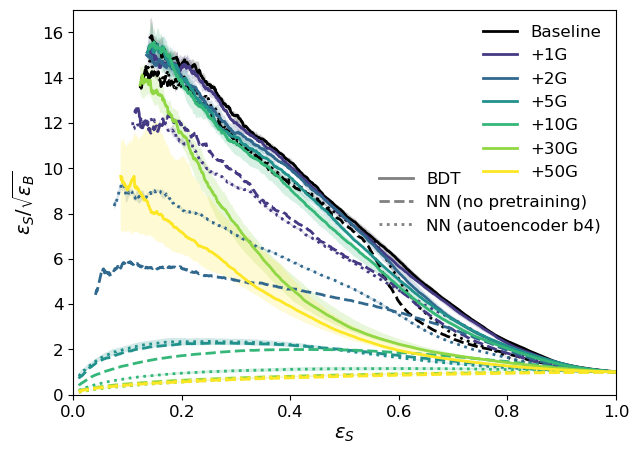

In [11]:
rows = [
    ("Baseline", col_bas, "IAD_baseline_NN/", "IAD_baseline_BDT/", "IAD_NN_autoencoder_b4_baseline/", "50_temp", 2),
    ("+1G",  col_1G,  "IAD_NN_1G/",  "IAD_BDT_1G/",  "IAD_NN_autoencoder_b4_1G/",  "50_temp", 2),
    ("+2G",  col_2G,  "IAD_NN_2G/",  "IAD_BDT_2G/",  "IAD_NN_autoencoder_b4_2G/",  "50_temp", 2),
    ("+5G",  col_5G,  "IAD_NN_5G/",  "IAD_BDT_5G/",  "IAD_NN_autoencoder_b4_5G/",  "50_temp", 2),
    ("+10G", col_10G, "IAD_NN_10G/", "IAD_BDT_10G/", "IAD_NN_autoencoder_b4_10G/", "50_temp", 2),
    ("+30G", col_30G, "IAD_NN_30G/", "IAD_BDT_30G/", "IAD_NN_autoencoder_b4_30G/", "50_temp", 2),
    ("+50G", col_50G, "IAD_NN_50G/", "IAD_BDT_50G/", "IAD_NN_autoencoder_b4_50G/", "50_temp", 2),
]
plot_comparison("fig2_autoencoder_b4", rows, "NN (autoencoder b4)", ylim=YLIM_FIG2)

## Fig 3 — Extended feature sets

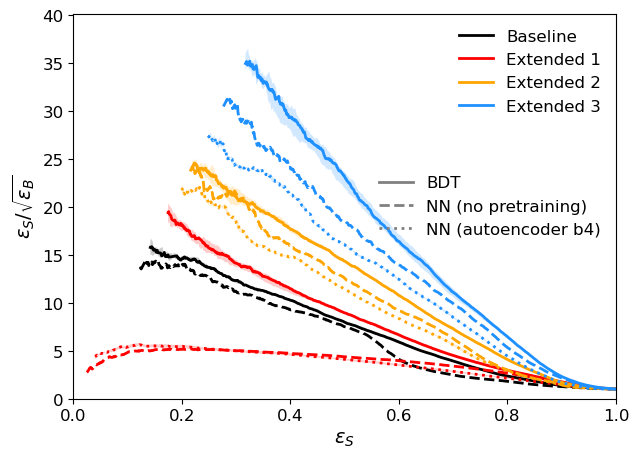

In [12]:
rows = [
    ("Baseline",   col_bas, "IAD_baseline_NN/",  "IAD_baseline_BDT/",  None,                                  None,      0),
    ("Extended 1", col_ex1, "IAD_NN_extended1/", "IAD_BDT_extended1/", "IAD_NN_autoencoder_b4_extended1/",    "50_temp", 2),
    ("Extended 2", col_ex2, "IAD_NN_extended2/", "IAD_BDT_extended2/", "IAD_NN_autoencoder_b4_extended2/",    "50_temp", 2),
    ("Extended 3", col_ex3, "IAD_NN_extended3/", "IAD_BDT_extended3/", "IAD_NN_autoencoder_b4_extended3/",    "50_temp", 2),
]
plot_comparison("fig3_autoencoder_b4", rows, "NN (autoencoder b4)", ylim=YLIM_FIG3)

---
# 4. Masked Feature Prediction (MFP)

## Fig 2 — Gaussian noise

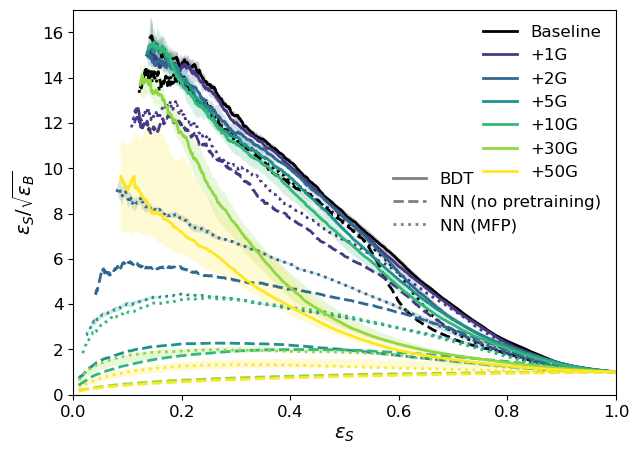

In [13]:
rows = [
    ("Baseline", col_bas, "IAD_baseline_NN/", "IAD_baseline_BDT/", "IAD_NN_mfp_baseline/", "50_temp", 1),
    ("+1G",  col_1G,  "IAD_NN_1G/",  "IAD_BDT_1G/",  "IAD_NN_mfp_1G/",  "50_temp", 1),
    ("+2G",  col_2G,  "IAD_NN_2G/",  "IAD_BDT_2G/",  "IAD_NN_mfp_2G/",  "50_temp", 2),
    ("+5G",  col_5G,  "IAD_NN_5G/",  "IAD_BDT_5G/",  "IAD_NN_mfp_5G/",  "50_temp", 2),
    ("+10G", col_10G, "IAD_NN_10G/", "IAD_BDT_10G/", "IAD_NN_mfp_10G/", "50_temp", 1),
    ("+30G", col_30G, "IAD_NN_30G/", "IAD_BDT_30G/", "IAD_NN_mfp_30G/", "50_temp", 3),
    ("+50G", col_50G, "IAD_NN_50G/", "IAD_BDT_50G/", "IAD_NN_mfp_50G/", "50_temp", 3),
]
plot_comparison("fig2_mfp", rows, "NN (MFP)", ylim=YLIM_FIG2)

## Fig 3 — Extended feature sets

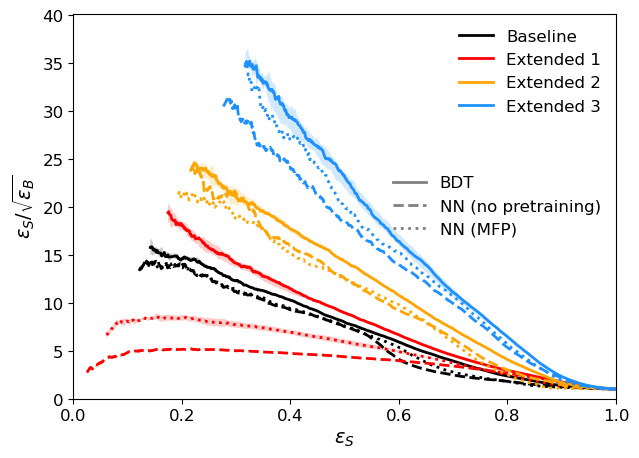

In [14]:
rows = [
    ("Baseline",   col_bas, "IAD_baseline_NN/",  "IAD_baseline_BDT/",  "IAD_NN_mfp_baseline/",  "50_temp", 1),
    ("Extended 1", col_ex1, "IAD_NN_extended1/", "IAD_BDT_extended1/", "IAD_NN_mfp_extended1/", "50_temp", 2),
    ("Extended 2", col_ex2, "IAD_NN_extended2/", "IAD_BDT_extended2/", "IAD_NN_mfp_extended2/", "50_temp", 1),
    ("Extended 3", col_ex3, "IAD_NN_extended3/", "IAD_BDT_extended3/", "IAD_NN_mfp_extended3/", "50_temp", 1),
]
plot_comparison("fig3_mfp", rows, "NN (MFP)", ylim=YLIM_FIG3)

---
# 5. SCARF SSL

## Fig 2 — Gaussian noise

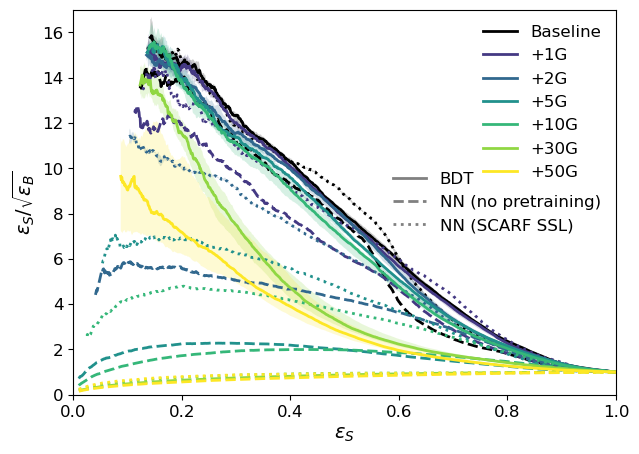

In [15]:
rows = [
    ("Baseline", col_bas, "IAD_baseline_NN/", "IAD_baseline_BDT/", "IAD_NN_scarfssl_baseline/", "50_temp", 2),
    ("+1G",  col_1G,  "IAD_NN_1G/",  "IAD_BDT_1G/",  "IAD_NN_scarfssl_1G/",  "50_temp", 1),
    ("+2G",  col_2G,  "IAD_NN_2G/",  "IAD_BDT_2G/",  "IAD_NN_scarfssl_2G/",  "50_temp", 2),
    ("+5G",  col_5G,  "IAD_NN_5G/",  "IAD_BDT_5G/",  "IAD_NN_scarfssl_5G/",  "50_temp", 1),
    ("+10G", col_10G, "IAD_NN_10G/", "IAD_BDT_10G/", "IAD_NN_scarfssl_10G/", "50_temp", 1),
    ("+30G", col_30G, "IAD_NN_30G/", "IAD_BDT_30G/", "IAD_NN_scarfssl_30G/", "50_temp", 1),
    ("+50G", col_50G, "IAD_NN_50G/", "IAD_BDT_50G/", "IAD_NN_scarfssl_50G/", "50_temp", 1),
]
plot_comparison("fig2_scarfssl", rows, "NN (SCARF SSL)", ylim=YLIM_FIG2)

## Fig 3 — Extended feature sets

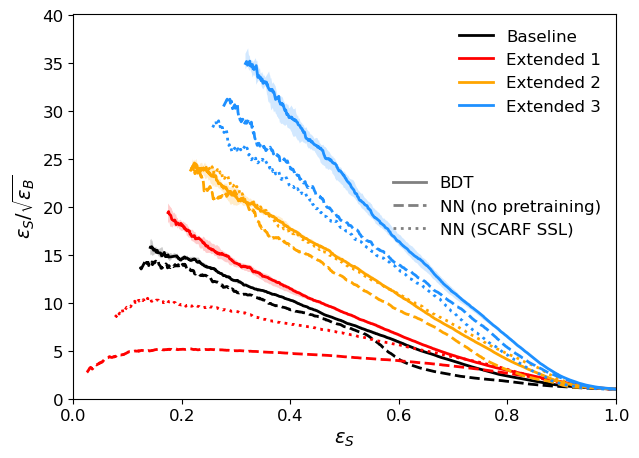

In [16]:
rows = [
    ("Baseline",   col_bas, "IAD_baseline_NN/",  "IAD_baseline_BDT/",  None,                           None,      0),
    ("Extended 1", col_ex1, "IAD_NN_extended1/", "IAD_BDT_extended1/", "IAD_NN_scarfssl_extended1/",   "50_temp", 1),
    ("Extended 2", col_ex2, "IAD_NN_extended2/", "IAD_BDT_extended2/", "IAD_NN_scarfssl_extended2/",   "50_temp", 1),
    ("Extended 3", col_ex3, "IAD_NN_extended3/", "IAD_BDT_extended3/", "IAD_NN_scarfssl_extended3/",   "50_temp", 1),
]
plot_comparison("fig3_scarfssl", rows, "NN (SCARF SSL)", ylim=YLIM_FIG3)

---
# Cross-method comparison

One plot per condition (baseline, 2G–50G, extended 1–3). Each shows BDT, NN (no pretraining), and all available pretraining methods.

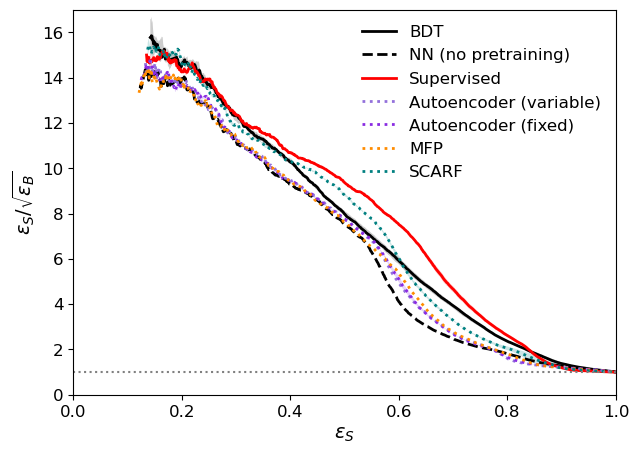

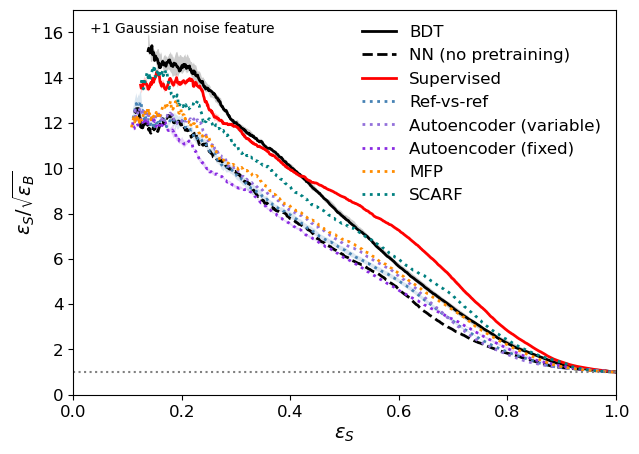

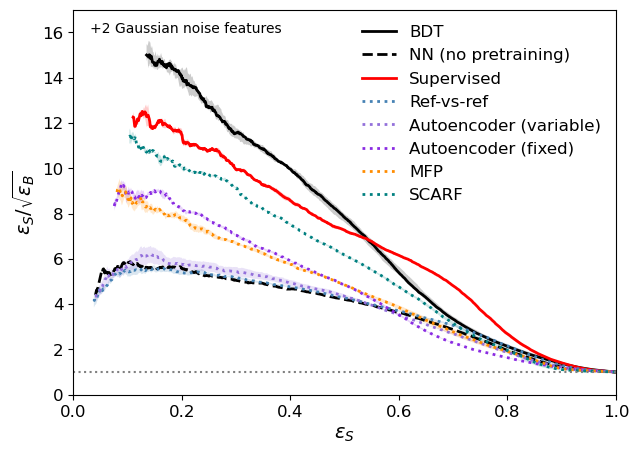

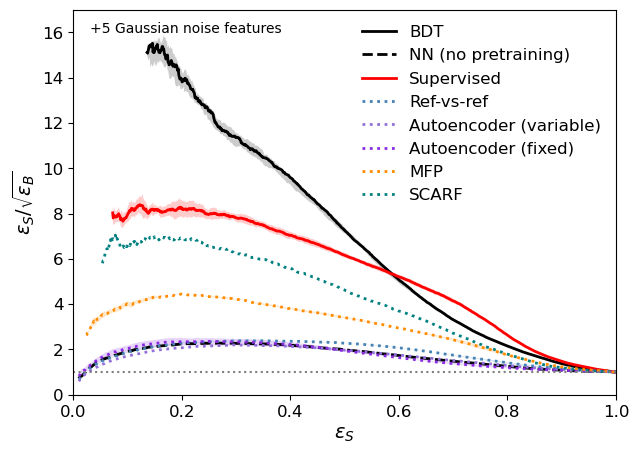

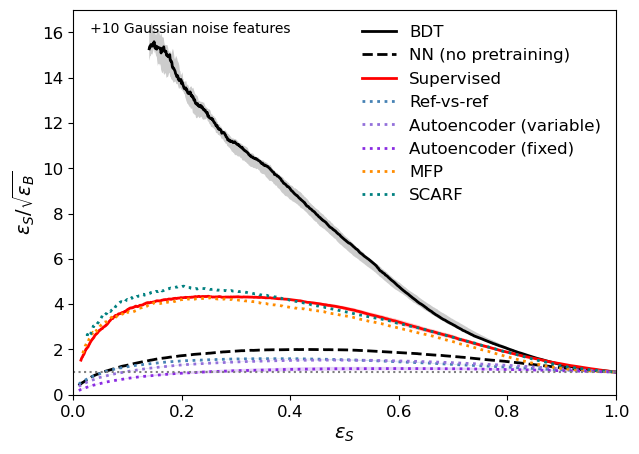

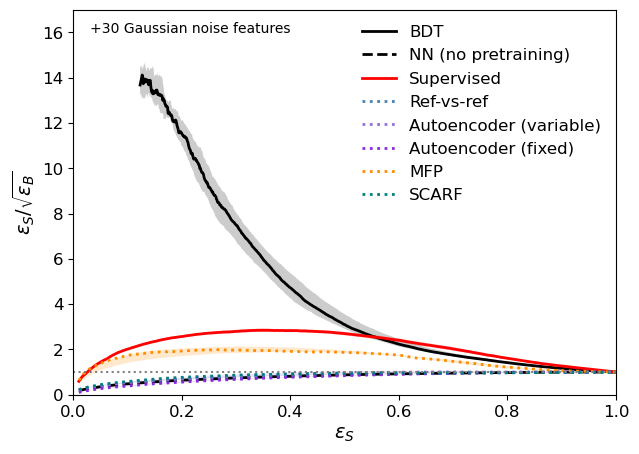

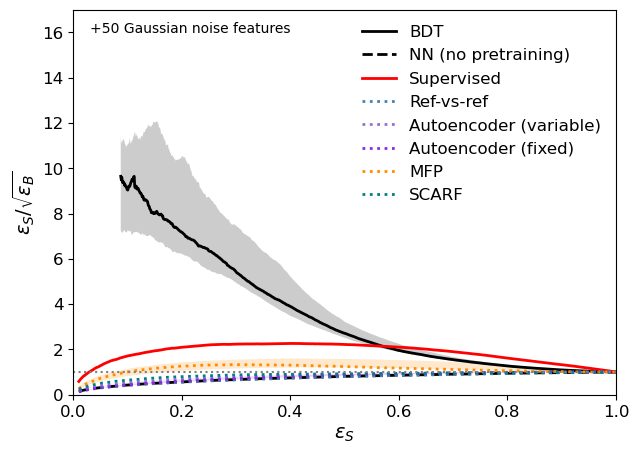

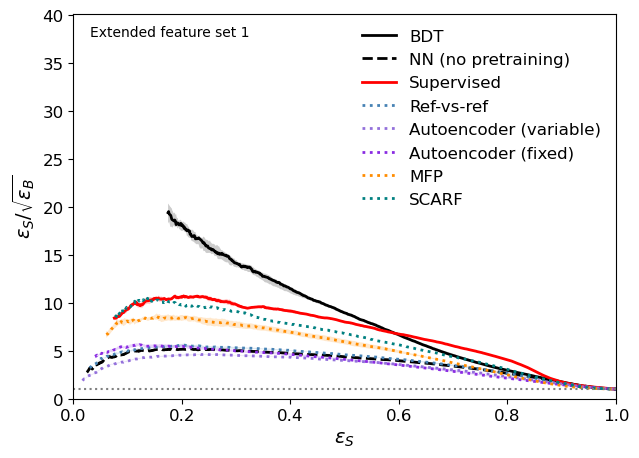

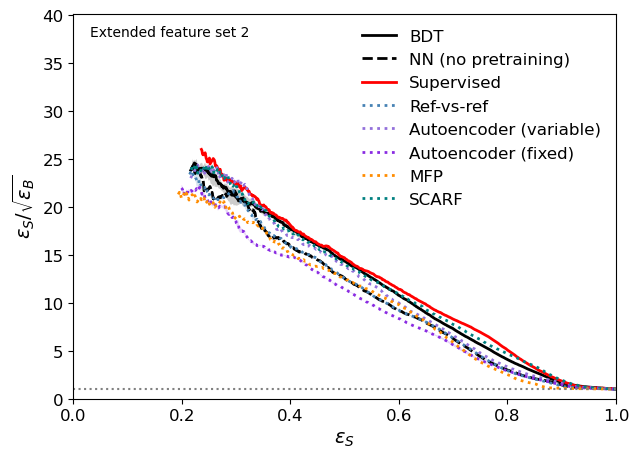

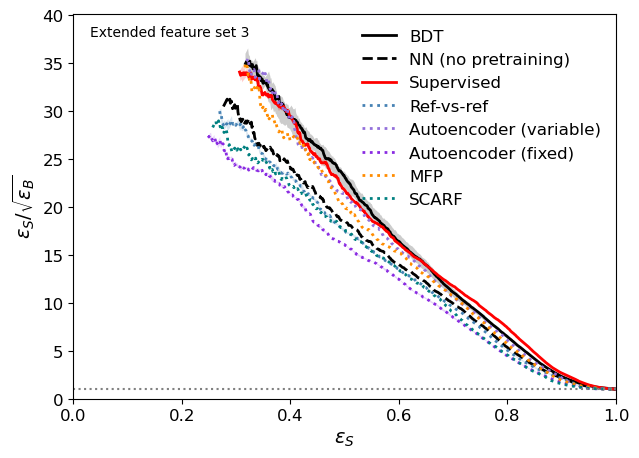

In [17]:
col_refvsref       = "steelblue"
col_supervised     = "red"
col_autoencoder    = "mediumpurple"
col_autoencoder_b4 = "blueviolet"
col_mfp            = "darkorange"
col_scarfssl       = "teal"

# (name, color, linestyle) — order must match method_specs tuples below
METHODS = [
    ("Supervised",             col_supervised,     "solid"),
    ("Ref-vs-ref",             col_refvsref,       "dotted"),
    ("Autoencoder (variable)",    col_autoencoder,    "dotted"),
    ("Autoencoder (fixed)", col_autoencoder_b4, "dotted"),
    ("MFP",                    col_mfp,            "dotted"),
    ("SCARF",                  col_scarfssl,       "dotted"),
]

# (plot_label, note, bdt_dir, nn_dir, ylim,
#  [(method_dir, ens_file, n_ens), ...])   — None method_dir → not yet available (< 50 runs)
conditions = [
    ("baseline",  None,
     "IAD_baseline_BDT/",  "IAD_baseline_NN/",  YLIM_FIG2,
     [("IAD_NN_supervised_baseline/",     "50_temp",  2),
      (None,                              None,       0),
      ("IAD_NN_autoencoder_baseline/",    "50_temp",  1),
      ("IAD_NN_autoencoder_b4_baseline/", "50_temp",  2),
      ("IAD_NN_mfp_baseline/",            "50_temp",  1),
      ("IAD_NN_scarfssl_baseline/",       "50_temp",  2)]),

    ("1G",  "+1 Gaussian noise feature",
     "IAD_BDT_1G/",  "IAD_NN_1G/",  YLIM_FIG2,
     [("IAD_NN_supervised_1G/",           "50_temp",  2),
      ("IAD_NN_pretrained_1G/",           "50_temp",  2),
      ("IAD_NN_autoencoder_1G/",          "50_temp",  1),
      ("IAD_NN_autoencoder_b4_1G/",       "50_temp",  2),
      ("IAD_NN_mfp_1G/",                  "50_temp",  1),
      ("IAD_NN_scarfssl_1G/",             "50_temp",  1)]),

    ("2G",  "+2 Gaussian noise features",
     "IAD_BDT_2G/",  "IAD_NN_2G/",  YLIM_FIG2,
     [("IAD_NN_supervised_2G/",           "50_temp",  2),
      ("IAD_NN_pretrained_2G/",           "50_temp",  2),
      ("IAD_NN_autoencoder_2G/",          "50_temp",  2),
      ("IAD_NN_autoencoder_b4_2G/",       "50_temp",  2),
      ("IAD_NN_mfp_2G/",                  "50_temp",  2),
      ("IAD_NN_scarfssl_2G/",             "50_temp",  2)]),

    ("5G",  "+5 Gaussian noise features",
     "IAD_BDT_5G/",  "IAD_NN_5G/",  YLIM_FIG2,
     [("IAD_NN_supervised_5G/",           "50_temp",  2),
      ("IAD_NN_pretrained_5G/",           "50_temp",  2),
      ("IAD_NN_autoencoder_5G/",          "50_temp",  2),
      ("IAD_NN_autoencoder_b4_5G/",       "50_temp",  2),
      ("IAD_NN_mfp_5G/",                  "50_temp",  2),
      ("IAD_NN_scarfssl_5G/",             "50_temp",  1)]),

    ("10G", "+10 Gaussian noise features",
     "IAD_BDT_10G/", "IAD_NN_10G/", YLIM_FIG2,
     [("IAD_NN_supervised_10G/",          "50_temp",  2),
      ("IAD_NN_pretrained_10G/",          "50_temp",  2),
      ("IAD_NN_autoencoder_10G/",         "50_temp",  2),
      ("IAD_NN_autoencoder_b4_10G/",      "50_temp",  2),
      ("IAD_NN_mfp_10G/",                 "50_temp",  1),
      ("IAD_NN_scarfssl_10G/",            "50_temp",  1)]),

    ("30G", "+30 Gaussian noise features",
     "IAD_BDT_30G/", "IAD_NN_30G/", YLIM_FIG2,
     [("IAD_NN_supervised_30G/",          "50_temp",  2),
      ("IAD_NN_pretrained_30G/",          "50_temp",  2),
      ("IAD_NN_autoencoder_30G/",         "50_temp",  2),
      ("IAD_NN_autoencoder_b4_30G/",      "50_temp",  2),
      ("IAD_NN_mfp_30G/",                 "50_temp",  3),
      ("IAD_NN_scarfssl_30G/",            "50_temp",  1)]),

    ("50G", "+50 Gaussian noise features",
     "IAD_BDT_50G/", "IAD_NN_50G/", YLIM_FIG2,
     [("IAD_NN_supervised_50G/",          "50_temp",  2),
      ("IAD_NN_pretrained_50G/",          "50_temp",  2),
      ("IAD_NN_autoencoder_50G/",         "50_temp",  2),
      ("IAD_NN_autoencoder_b4_50G/",      "50_temp",  2),
      ("IAD_NN_mfp_50G/",                 "50_temp",  3),
      ("IAD_NN_scarfssl_50G/",            "50_temp",  1)]),

    ("extended1", "Extended feature set 1",
     "IAD_BDT_extended1/", "IAD_NN_extended1/", YLIM_FIG3,
     [("IAD_NN_supervised_extended1/",    "50_temp",  2),
      ("IAD_NN_pretrained_extended1/",    "50_temp",  2),
      ("IAD_NN_autoencoder_extended1/",   "50_temp",  2),
      ("IAD_NN_autoencoder_b4_extended1/","50_temp",  2),
      ("IAD_NN_mfp_extended1/",           "50_temp",  2),
      ("IAD_NN_scarfssl_extended1/",      "50_temp",  1)]),

    ("extended2", "Extended feature set 2",
     "IAD_BDT_extended2/", "IAD_NN_extended2/", YLIM_FIG3,
     [("IAD_NN_supervised_extended2/",    "50_temp",  2),
      ("IAD_NN_pretrained_extended2/",    "50_temp",  2),
      ("IAD_NN_autoencoder_extended2/",   "50_temp",  1),
      ("IAD_NN_autoencoder_b4_extended2/","50_temp",  2),
      ("IAD_NN_mfp_extended2/",           "50_temp",  1),
      ("IAD_NN_scarfssl_extended2/",      "50_temp",  1)]),

    ("extended3", "Extended feature set 3",
     "IAD_BDT_extended3/", "IAD_NN_extended3/", YLIM_FIG3,
     [("IAD_NN_supervised_extended3/",    "50_temp",  2),
      ("IAD_NN_pretrained_extended3/",    "50_temp",  2),
      ("IAD_NN_autoencoder_extended3/",   "50_temp",  1),
      ("IAD_NN_autoencoder_b4_extended3/","50_temp",  2),
      ("IAD_NN_mfp_extended3/",           "50_temp",  1),
      ("IAD_NN_scarfssl_extended3/",      "50_temp",  1)]),
]

for plot_label, note, bdt_dir, nn_dir, ylim, method_specs in conditions:
    plt.figure(figsize=FIGSIZE)
    import_and_plot("roc_classifier_averaging",
                    label="BDT", color="black", linestyle="solid", folder=RES + bdt_dir)
    import_and_plot(NN_runs + "_temp",
                    label="NN (no pretraining)", color="black", linestyle="dashed",
                    folder=RES + nn_dir, N_runs=1)
    for (name, color, ls), (mdir, ens, nens) in zip(METHODS, method_specs):
        if mdir is not None:
            import_and_plot(ens, label=name, color=color, linestyle=ls,
                            folder=RES + mdir, N_runs=nens)
    plt.axhline(1, color="grey", linestyle="dotted", linewidth=1.5)
    if note:
        plt.gca().text(0.03, 0.97, note, transform=plt.gca().transAxes, va="top", ha="left")
    plot_end("fig_all_methods_" + plot_label, ylim=ylim)
